## Load dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("students.csv")

print("Dataset loaded successfully.\n")

Dataset loaded successfully.



## Task 1 — Data Exploration with Pandas 
## Show first 5 rows

In [3]:
print("First 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


## Show shape of dataset

In [4]:
print("\nShape of dataset:")
print(df.shape)


Shape of dataset:
(15, 9)


## Show data types

In [5]:
print("\nData types of each column:")
print(df.dtypes)


Data types of each column:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


## Show summary statistics

In [6]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               

## Count how many students passed and failed

In [7]:
print("Number of students who passed:", df["passed"].value_counts()[1])
print("Number of students who failed:", df["passed"].value_counts()[0])

Number of students who passed: 9
Number of students who failed: 6


## Store subject names in a list

In [8]:
subject_cols = ["math", "science", "english", "history", "pe"]


## Average marks of students who passed

In [9]:
passing_students = df[df["passed"] == 1]
passing_avg = passing_students[subject_cols].mean()

print("\nAverage subject scores for passing students:")
print(passing_avg)


Average subject scores for passing students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64


## Average marks of students who failed

In [10]:
failing_students = df[df["passed"] == 0]
failing_avg = failing_students[subject_cols].mean()

print("\nAverage subject scores for failing students:")
print(failing_avg)



Average subject scores for failing students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


## new column for overall average

In [11]:
df["average_score"] = df[subject_cols].mean(axis=1)

## student with the highest average

In [12]:
top_student = df.loc[df["average_score"].idxmax()]

print("\nStudent with the highest overall average:")
print(top_student[["name", "average_score"]])


Student with the highest overall average:
name             Diana
average_score     94.0
Name: 3, dtype: object


## Observation

From the data, I can see that students who passed have higher average marks in all subjects compared to students who failed. The student with the highest overall average scored well in all five subjects.

In [13]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Task 2 — Data Visualization with Matplotlib

## Import matplotlib

In [14]:
import matplotlib.pyplot as plt
print("matplotlib imported successfully")

matplotlib imported successfully


In [15]:
import matplotlib.pyplot as plt

## Create the avg_score column

In [16]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

print(df[['name', 'avg_score']].head())

      name  avg_score
0    Alice       86.2
1      Bob       51.0
2  Charlie       76.2
3    Diana       94.0
4      Eve       46.0


## Plot 1 — Bar Chart
## Average score per subject across all students

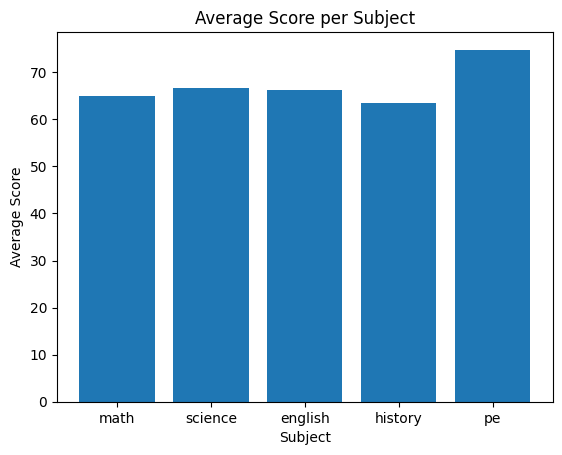

In [17]:
subject_avg = df[subject_cols].mean()

plt.bar(subject_avg.index, subject_avg.values)
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

## Plot 2 — Histogram
## Distribution of math scores

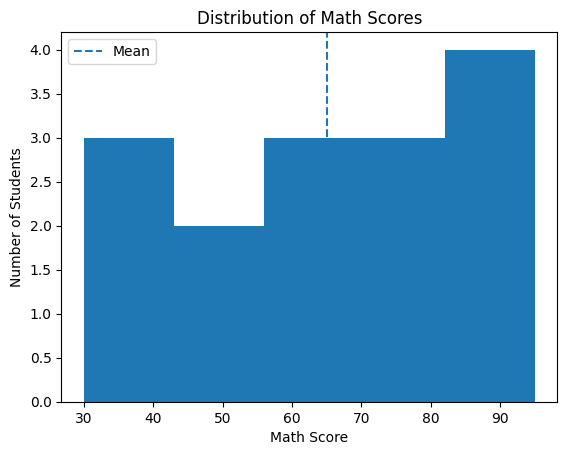

In [18]:
math_mean = df['math'].mean()

plt.hist(df['math'], bins=5)
plt.axvline(math_mean, linestyle='--', label='Mean')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

## Plot 3 — Scatter Plot
## Study hours per day vs average score

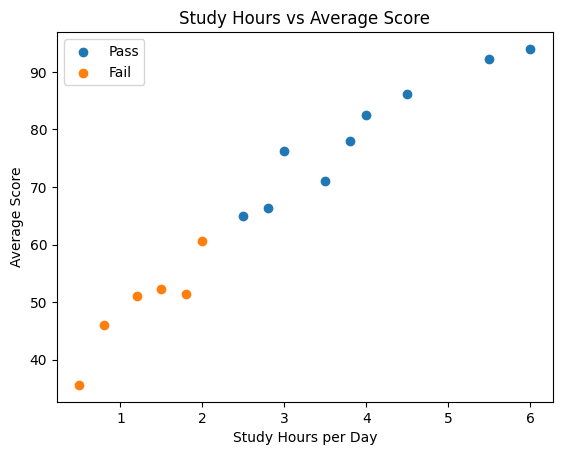

In [19]:
pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label='Pass')
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

## Plot 4 — Box Plot
## Attendance percentage for passing vs failing students

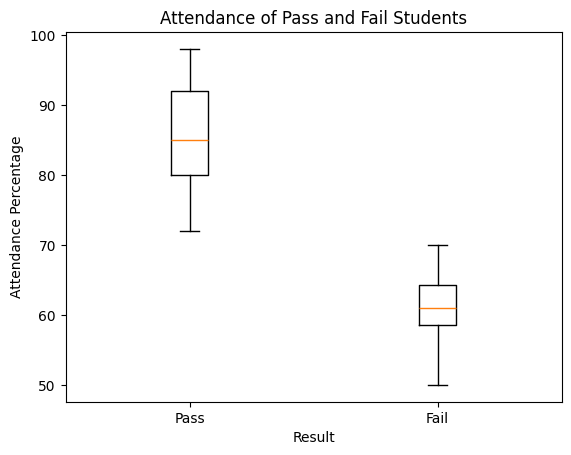

In [20]:
pass_attendance = df[df['passed'] == 1]['attendance_pct']
fail_attendance = df[df['passed'] == 0]['attendance_pct']

plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])
plt.title("Attendance of Pass and Fail Students")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_boxplot.png")
plt.show()

## Plot 5 — Line Plot
## Math and science score for every student

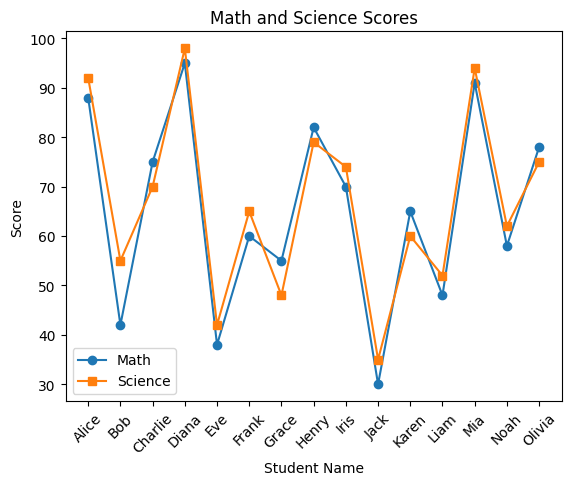

In [21]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')
plt.title("Math and Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

## Observation


The plots show that students who study more and have better attendance tend to perform better. 
The graphs also help compare subject scores and understand the distribution of marks.

## Task 3 — Data Visualization with Seaborn

In [22]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

## Seaborn bar plot 

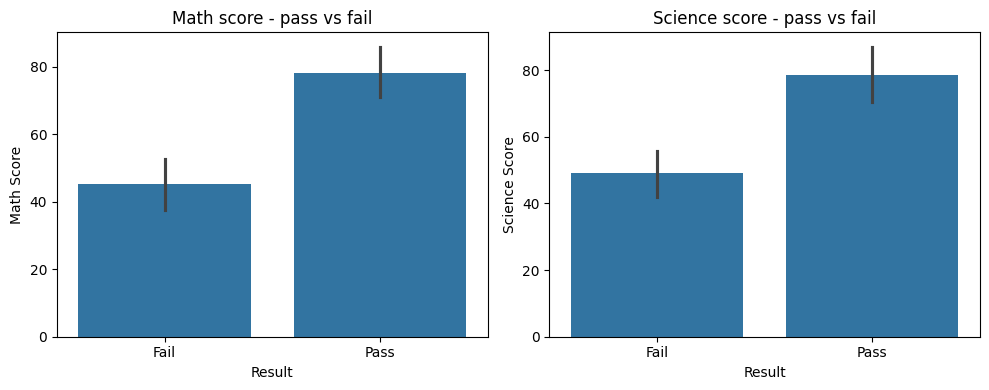

In [24]:


plt.figure(figsize=(10,4))

# math
ax1 = plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math score - pass vs fail")
ax1.set_xlabel("Result")
ax1.set_ylabel("Math Score")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Fail', 'Pass'])

# science
ax2 = plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Science score - pass vs fail")
ax2.set_xlabel("Result")
ax2.set_ylabel("Science Score")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

##  Seaborn scatter plot

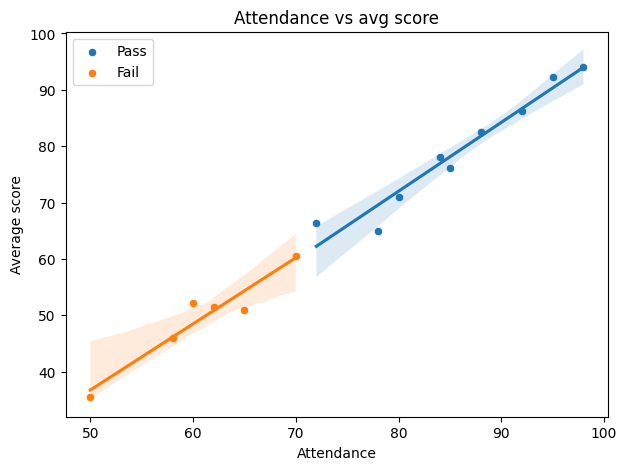

In [25]:

pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.figure(figsize=(7,5))

sns.scatterplot(data=pass_data, x='attendance_pct', y='avg_score', label='Pass')
sns.scatterplot(data=fail_data, x='attendance_pct', y='avg_score', label='Fail')

sns.regplot(data=pass_data, x='attendance_pct', y='avg_score', scatter=False)
sns.regplot(data=fail_data, x='attendance_pct', y='avg_score', scatter=False)

plt.title("Attendance vs avg score")
plt.xlabel("Attendance")
plt.ylabel("Average score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

## comment
  seaborn was easier to use because the graphs looked better without much effort.
  it was quick to create bar and scatter plots.
  matplotlib needed more manual work compared to seaborn.

## Task 4 — Machine Learning with scikit-learn

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Step 1 — Prepare Data

In [27]:


features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[features]
y = df['passed']

In [28]:
#Split into train (80%) and test (20%) sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
#Scale features using StandardScaler — fit on training data


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 2 — Train a Model:

In [30]:


model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
train_pred = model.predict(X_train_scaled)

print("training accuracy:", accuracy_score(y_train, train_pred))

training accuracy: 1.0


## Step 3 — Evaluate the Model:

In [32]:
y_pred = model.predict(X_test_scaled)

print("test accuracy:", accuracy_score(y_test, y_pred))

test accuracy: 1.0


In [33]:
# check each student result

names = df.loc[X_test.index, 'name']

for i in range(len(X_test)):
    name = names.iloc[i]

    actual = "Pass" if y_test.iloc[i] == 1 else "Fail"
    pred = "Pass" if y_pred[i] == 1 else "Fail"

    if actual == pred:
        status = "correct"
    else:
        status = "wrong"

    print(name, "| actual:", actual, "| predicted:", pred, "|", status)

Jack | actual: Fail | predicted: Fail | correct
Liam | actual: Fail | predicted: Fail | correct
Alice | actual: Pass | predicted: Pass | correct


## Step 4 — Feature Importance:

In [34]:


coefs = model.coef_[0]

pairs = list(zip(features, coefs))

# sorted by absolute value
pairs.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nfeature importance:")
for f, c in pairs:
    print(f, ":", c)


feature importance:
english : 0.8125127982724648
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155
pe : 0.47497406284967797
math : 0.43794393086873595
science : 0.3230097624690249
history : 0.26292892629062437


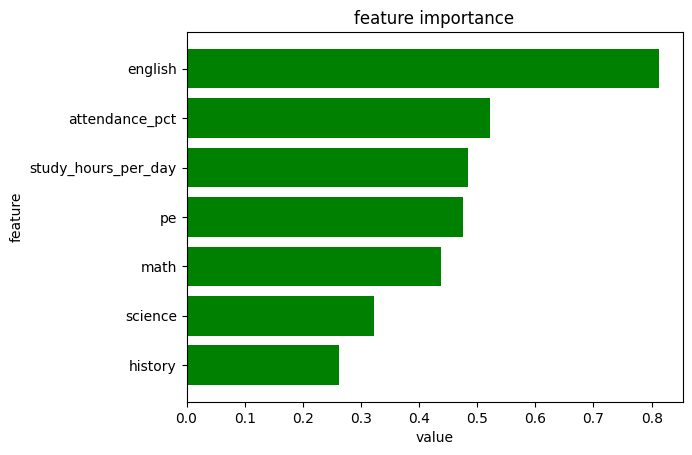

In [35]:
# Create a horizontal bar chart 

names = [p[0] for p in pairs]
values = [p[1] for p in pairs]

colors = ['green' if v > 0 else 'red' for v in values]

plt.barh(names, values, color=colors)
plt.title("feature importance")
plt.xlabel("value")
plt.ylabel("feature")
plt.gca().invert_yaxis()
plt.show()

## Step 5 — Predict for a New Student 

In [36]:


new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

if pred[0] == 1:
    print("prediction: Pass")
else:
    print("prediction: Fail")

print("probability:", prob)

prediction: Pass
probability: [[0.09203526 0.90796474]]


c:\Users\panch\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


 ## commment 
 this model predicts pass or fail based on student data.
 since dataset is small, accuracy may not be perfect.
 but it helps understand the ML steps.